# Proyek Analisis Data: Bike Sharing
- **Nama:** Sabia Putri Aulia
- **Email:** auliasabiaputri@gmail.com
- **ID Dicoding:** CDCC229D6X0989

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

1. Bagaimana pengaruh hari dalam seminggu terhadap jumlah penyewaan sepeda, dan hai apa yang menunjukkan tingkat penggunaan paling tinggi?
2. Bagaimana musim mempengaruhi pola penggunaan sepeda antara pengguna casual dan registered, dan kategori pengguna mana yang paling sensitif terhadap perubahan musim?
3. Pada jam berapa rata-rata penyewaan sepeda mencapai nilai tertinggi dalam satu hari, dan bagaimana distribusinya sepanjang waktu?
4. Bagaimana perbedaan rata-rata jumlah pengguna casual dan registered pada setiap musim, serta musim mana yang memiliki total penyewaan sepeda tertinggi?
5. Apakah kecepatan angin memiliki hubungan terhadap jumlah penyewaan sepeda, dan apakah pengaruhnya signifikan?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## Data Wrangling

### Gathering Data

Load Tabel Hari

In [ ]:
hari_df = pd.read_csv("day.csv")
hari_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Load Tabel Jam

In [ ]:
jam_df = pd.read_csv("hour.csv")
jam_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

Steps To Take:
1. Mengecek Tipe Data
2. Mengecek Missing Value
3. Mengecek Duplicate Data
4. Mengecek Nilai Statistik

#### Menilai hari_df

1. Mengecek Tipe Data hari_df

In [ ]:
hari_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


2. Mengecek Missing Value

In [ ]:
hari_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


3. Mengecek Duplicate Data

In [ ]:
print("Jumlah duplikasi: ", hari_df.duplicated().sum())

Jumlah duplikasi:  0


4. Mengecek Nilai Statistik

In [ ]:
hari_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Menilai jam_df

1. Mengecek Info jam_df

In [ ]:
jam_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


2. Mengecek Missing Value

In [ ]:
jam_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


3. Mengecek Duplicate Data

In [ ]:
print("Jumlah duplikasi: ", jam_df.duplicated().sum())

Jumlah duplikasi:  0


4. Mengecek Nilai Statistik

In [ ]:
jam_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Cleaning Data

#### Cleaning Bagian hari_df

1. Menghapus beberapa kolom yang tidak digunakan

In [ ]:
drop_columns = ['temp', 'atemp', 'hum', 'instant']

for i in hari_df.columns:
  if i in drop_columns:
    hari_df.drop(labels=i, axis=1, inplace=True)

hari_df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.186900,82,1518,1600


2. Mengubah Detail Nama

In [ ]:
hari_df.rename(columns={
    'dteday' : 'dateday',
    'yr' : 'year',
    'mnth' : 'month',
    'weathersit' : 'weather',
    'cnt' : 'count'
}, inplace=True)

hari_df.head()

,dateday,season,year,month,holiday,weekday,workingday,weather,windspeed,casual,registered,count
0,2011-01-01,1,0,1,0,6,0,2,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.186900,82,1518,1600


In [ ]:
hari_df['month'] = hari_df['month'].map({
    1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 7: 'Juli',
    8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'
})

hari_df['season'] = hari_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

hari_df['weather'] = hari_df['weather'].map({
 1: 'Clear, Cloudy',
  2: 'LIght Mist',
  3: 'Light Snow, Thunderstorm',
  4: 'Foggy Snow'
})

hari_df['weekday'] = hari_df['weekday'].map({
  0: 'Minggu', 1: 'Senin', 2: 'Selasa', 3: 'Rabu', 4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'
})

3. Memperbaiki Tipe Data

In [ ]:
datetime_columns = ["dateday"]

for column in datetime_columns:
  hari_df[column] = pd.to_datetime(hari_df[column])

In [ ]:
category_columns = ["season", "year", "month", "workingday", "weather", "holiday", "weekday"]

for column in category_columns:
  hari_df[column] = hari_df[column].astype('category')

In [ ]:
hari_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dateday     731 non-null    datetime64[ns]
 1   season      731 non-null    category      
 2   year        731 non-null    category      
 3   month       731 non-null    category      
 4   holiday     731 non-null    category      
 5   weekday     731 non-null    category      
 6   workingday  731 non-null    category      
 7   weather     731 non-null    category      
 8   windspeed   731 non-null    float64       
 9   casual      731 non-null    int64         
 10  registered  731 non-null    int64         
 11  count       731 non-null    int64         
dtypes: category(7), datetime64[ns](1), float64(1), int64(3)
memory usage: 35.1 KB


Cleaning Bagian jam_df

In [ ]:
drop_columns = ['temp', 'atemp', 'hum', 'instant']

for i in jam_df.columns:
  if i in drop_columns:
    jam_df.drop(labels=i, axis=1, inplace=True)

jam_df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.0,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.0,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.0,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.0,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.0,0,1,1


In [ ]:
jam_df.rename(columns={
    'dteday' : 'dateday',
    'yr' : 'year',
    'mnth' : 'month',
    'weathersit' : 'weather',
    'hr' : 'hour',
    'cnt' : 'count'
}, inplace=True)

jam_df.head()

,dateday,season,year,month,hour,holiday,weekday,workingday,weather,windspeed,casual,registered,count
0,2011-01-01,1,0,1,0,0,6,0,1,0.0,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.0,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.0,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.0,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.0,0,1,1


In [ ]:
jam_df['month'] = jam_df['month'].map({
    1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 7: 'Juli',
    8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'
})

jam_df['season'] = jam_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

jam_df['weather'] = jam_df['weather'].map({
  1: 'Clear, Cloudy',
  2: 'LIght Mist',
  3: 'Light Snow, Thunderstorm',
  4: 'Foggy Snow'
})

jam_df['weekday'] = jam_df['weekday'].map({
  0: 'Minggu', 1: 'Senin', 2: 'Selasa', 3: 'Rabu', 4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'
})

In [ ]:
datetime_columns = ["dateday"]

for column in datetime_columns:
  jam_df[column] = pd.to_datetime(jam_df[column])

In [ ]:
category_columns = ["season", "year", "month", "workingday", "weather", "holiday", "weekday"]

for column in category_columns:
  jam_df[column] = jam_df[column].astype('category')

In [ ]:
jam_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dateday     17379 non-null  datetime64[ns]
 1   season      17379 non-null  category      
 2   year        17379 non-null  category      
 3   month       17379 non-null  category      
 4   hour        17379 non-null  int64         
 5   holiday     17379 non-null  category      
 6   weekday     17379 non-null  category      
 7   workingday  17379 non-null  category      
 8   weather     17379 non-null  category      
 9   windspeed   17379 non-null  float64       
 10  casual      17379 non-null  int64         
 11  registered  17379 non-null  int64         
 12  count       17379 non-null  int64         
dtypes: category(7), datetime64[ns](1), float64(1), int64(4)
memory usage: 935.1 KB


In [ ]:
hari_df.to_csv("hari_all_data.csv", index=False)

In [ ]:
jam_df.to_csv("jam_all_data.csv", index=False)

## Exploratory Data Analysis (EDA)

1. Pengelompokkan Penyewa Sepeda Berdasarkan Tahun

In [ ]:
hari_df.groupby(by='year').agg({
    'count' : ['min', 'max', 'mean', 'sum']
})

/tmp/ipykernel_32558/1233159857.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hari_df.groupby(by='year').agg({


count                            
       min   max         mean      sum
year                                  
0      431  6043  3405.761644  1243103
1       22  8714  5599.934426  2049576

2. Pengelompokkan Penyewa Sepeda Berdasarkan Bulan

In [ ]:
hari_df.groupby(by='month').agg({
    'count' : ['min', 'max', 'mean', 'sum']
})

/tmp/ipykernel_32558/4277754207.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hari_df.groupby(by='month').agg({


count                           
            min   max         mean     sum
month                                     
Agustus    1115  7865  5664.419355  351194
April       795  7460  4484.900000  269094
Desember    441  6606  3403.806452  211036
Februari   1005  5062  2655.298246  151352
Januari     431  4521  2176.338710  134933
Juli       3285  8173  5563.677419  344948
Juni       3767  8120  5772.366667  346342
Maret       605  8362  3692.258065  228920
Mei        2633  8294  5349.774194  331686
November   1495  6852  4247.183333  254831
Oktober      22  8156  5199.225806  322352
September  1842  8714  5766.516667  345991

3. Pengelompokkan Penyewa Sepeda Berdasarkan Cuaca

In [ ]:
hari_df.groupby(by='weather').agg({
    'count' : ['min', 'max', 'mean', 'sum']
})

/tmp/ipykernel_32558/980006004.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hari_df.groupby(by='weather').agg({


count                            
                           min   max         mean      sum
weather                                                   
Clear, Cloudy              431  8714  4876.786177  2257952
LIght Mist                 605  8362  4035.862348   996858
Light Snow, Thunderstorm    22  4639  1803.285714    37869

4. Pengelompokkan Penyewa Sepeda Berdasarkan Season

In [ ]:
hari_df.groupby(by='season').agg({
    'count' : ['min', 'max', 'mean', 'sum']
})

/tmp/ipykernel_32558/3291619949.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hari_df.groupby(by='season').agg({


count                            
         min   max         mean      sum
season                                  
Fall    1115  8714  5644.303191  1061129
Spring   431  7836  2604.132597   471348
Summer   795  8362  4992.331522   918589
Winter    22  8555  4728.162921   841613

In [ ]:
hari_df.groupby(by='season').agg({
    'casual' : ['min', 'max', 'mean'],
    'registered' : ['min', 'max', 'mean'],
    'count' : ['min', 'max', 'mean', 'sum']
})

/tmp/ipykernel_32558/4085332878.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hari_df.groupby(by='season').agg({


casual                    registered                    count        \
          min   max         mean        min   max         mean   min   max   
season                                                                       
Fall      118  3160  1202.611702        889  6917  4441.691489  1115  8714   
Spring      9  3155   334.928177        416  5315  2269.204420   431  7836   
Summer    120  3410  1106.097826        674  6456  3886.233696   795  8362   
Winter      2  3031   729.112360         20  6946  3999.050562    22  8555   

                              
               mean      sum  
season                        
Fall    5644.303191  1061129  
Spring  2604.132597   471348  
Summer  4992.331522   918589  
Winter  4728.162921   841613

5. Pengelompokkan Penyewa Sepeda Berdasarkan Hari

In [ ]:
hari_df.groupby(by='weekday').agg({
    'count' : ['min', 'max', 'mean', 'sum']
})

/tmp/ipykernel_32558/4088415576.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hari_df.groupby(by='weekday').agg({


count                           
          min   max         mean     sum
weekday                                 
Jumat    1167  8362  4690.288462  487790
Kamis     431  7804  4667.259615  485395
Minggu    605  8227  4228.828571  444027
Rabu      441  8173  4548.538462  473048
Sabtu     627  8714  4550.542857  477807
Selasa    683  7767  4510.663462  469109
Senin      22  7525  4338.123810  455503

In [ ]:
hari_df.groupby(by='workingday').agg({
    'count' : ['min', 'max', 'mean', 'sum']
})

/tmp/ipykernel_32558/747134838.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hari_df.groupby(by='workingday').agg({


count                            
             min   max         mean      sum
workingday                                  
0            605  8714  4330.168831  1000269
1             22  8362  4584.820000  2292410

6. Pengelompokkan Penyewaan Sepeda Berdasarkan Jam

In [ ]:
jam_df.groupby(by='hour').agg({
    'count' : ['min', 'max', 'mean', 'sum']
})

count                         
       min  max        mean     sum
hour                               
0        2  283   53.898072   39130
1        1  168   33.375691   24164
2        1  132   22.869930   16352
3        1   79   11.727403    8174
4        1   28    6.352941    4428
5        1   66   19.889819   14261
6        1  213   76.044138   55132
7        1  596  212.064649  154171
8        5  839  359.011004  261001
9       14  426  219.309491  159438
10       8  539  173.668501  126257
11      10  663  208.143054  151320
12       3  776  253.315934  184414
13      11  760  253.661180  184919
14      12  750  240.949246  175652
15       7  750  251.233196  183149
16      11  783  311.983562  227748
17      15  976  461.452055  336860
18      23  977  425.510989  309772
19      11  743  311.523352  226789
20      11  567  226.030220  164550
21       6  584  172.314560  125445
22       9  502  131.335165   95612
23       2  256   87.831044   63941

7. Pengelompokkan Penyewaan Sepeda Berdasarkan Kecepatan Angin

In [ ]:
hari_df.groupby(by='weekday').agg({
    'windspeed' : ['min', 'max', 'sum'],
    'count' : ['min', 'max', 'sum']
})

/tmp/ipykernel_32558/3729614436.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hari_df.groupby(by='weekday').agg({


windspeed                      count              
              min       max        sum   min   max     sum
weekday                                                   
Jumat    0.022392  0.414800  19.384430  1167  8362  487790
Kamis    0.047275  0.441563  19.926720   431  7804  485395
Minggu   0.050379  0.409212  19.795638   605  8227  444027
Rabu     0.060958  0.415429  19.524592   441  8173  473048
Sabtu    0.045404  0.507463  20.641691   627  8714  477807
Selasa   0.053213  0.388067  19.949832   683  7767  469109
Senin    0.042304  0.417908  20.022517    22  7525  455503

## Visualization & Explanatory Analysis

1. Bagaimana pengaruh hari dalam seminggu terhadap jumlah penyewaan sepeda, dan hari apa yang menunjukkan tingkat penggunaan paling tinggi?


In [ ]:
hari_df.groupby(by='weekday').agg({
    'count' : ['min', 'max', 'mean', 'sum']
})

/tmp/ipykernel_32558/4088415576.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hari_df.groupby(by='weekday').agg({


count                           
          min   max         mean     sum
weekday                                 
Jumat    1167  8362  4690.288462  487790
Kamis     431  7804  4667.259615  485395
Minggu    605  8227  4228.828571  444027
Rabu      441  8173  4548.538462  473048
Sabtu     627  8714  4550.542857  477807
Selasa    683  7767  4510.663462  469109
Senin      22  7525  4338.123810  455503

/tmp/ipykernel_32558/3566812497.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_hari = hari_df.groupby(by='weekday')['count'].sum()


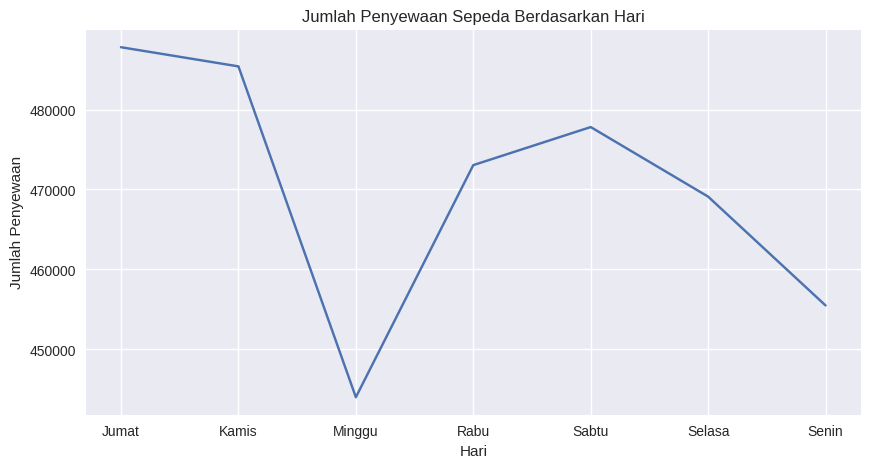

In [ ]:
plt.figure(figsize=(10, 5))

per_hari = hari_df.groupby(by='weekday')['count'].sum()

plt.plot(per_hari)
plt.title('Jumlah Penyewaan Sepeda Berdasarkan Hari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Penyewaan')
plt.show()

2. Bagaimana musim mempengaruhi pola penggunaan sepeda antara pengguna casual dan registered, dan kategori pengguna mana yang paling sensitif terhadap perubahan musim?


In [ ]:
hari_df.groupby(by='season').agg({
    'casual' : ['min', 'max', 'mean', 'sum'],
    'registered' : ['min', 'max', 'mean', 'sum']
})

/tmp/ipykernel_32558/2748409675.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hari_df.groupby(by='season').agg({


casual                            registered                           
          min   max         mean     sum        min   max         mean     sum
season                                                                        
Fall      118  3160  1202.611702  226091        889  6917  4441.691489  835038
Spring      9  3155   334.928177   60622        416  5315  2269.204420  410726
Summer    120  3410  1106.097826  203522        674  6456  3886.233696  715067
Winter      2  3031   729.112360  129782         20  6946  3999.050562  711831

/tmp/ipykernel_32558/469009703.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_musim = hari_df.groupby(by='season')[['casual', 'registered']].mean()


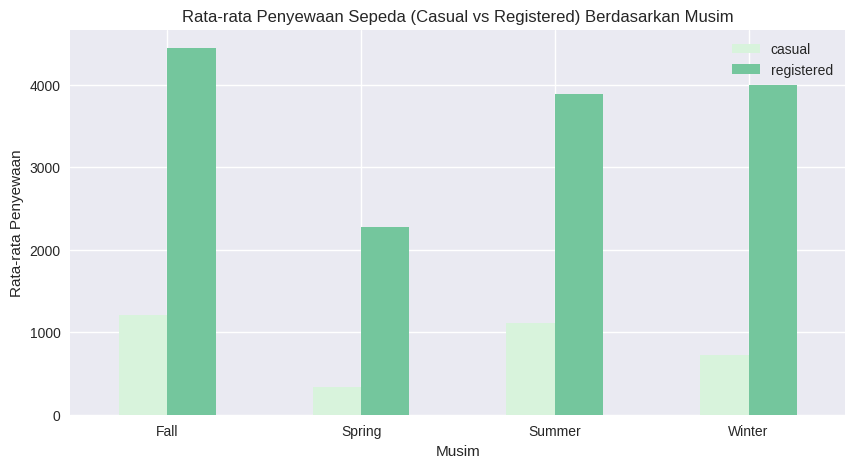

In [ ]:
per_musim = hari_df.groupby(by='season')[['casual', 'registered']].mean()

per_musim.plot(
    kind='bar',
    figsize=(10,5),
    color=['#D8F3DC', '#74C69D']
)

plt.title('Rata-rata Penyewaan Sepeda (Casual vs Registered) Berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(rotation=0)

plt.show()

3. Pada jam berapa rata-rata penyewaan sepeda mencapai nilai tertinggi dalam satu hari, dan bagaimana distribusinya sepanjang waktu?


In [ ]:
per_jam = jam_df.groupby(by='hour').agg({
    'count' : ['mean']
})

per_jam

,count
,mean
hour,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649


In [ ]:
mean_per_jam = per_jam[('count', 'mean')]

peak_hours = mean_per_jam.idxmax()
peak_value = mean_per_jam.max()

peak_hours, peak_value

(np.int64(17), 461.45205479452056)

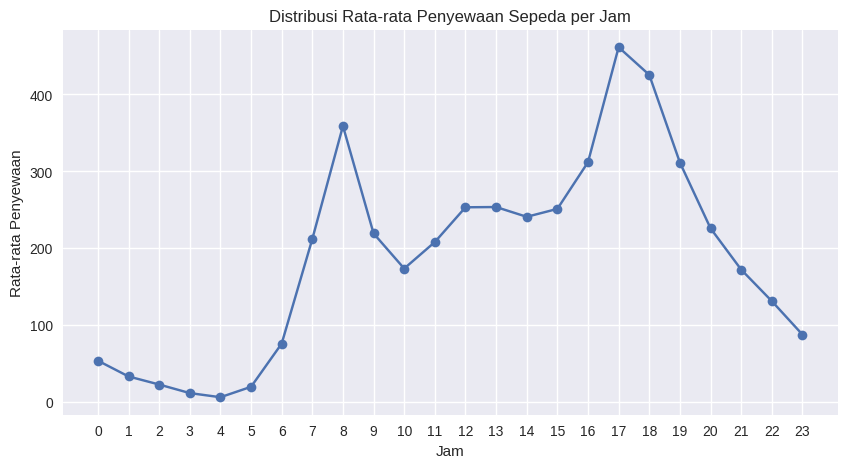

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(per_jam.index, mean_per_jam, marker='o')

plt.title('Distribusi Rata-rata Penyewaan Sepeda per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0,24))

plt.show()

4. Bagaimana perbedaan rata-rata jumlah pengguna casual dan registered pada setiap cuaca, serta cuaca mana yang memiliki total penyewaan sepeda tertinggi?


In [ ]:
cuaca = hari_df.groupby(by='weather').agg({
    'casual' : ['mean', ],
    'registered' : ['mean'],
    'count' : ['sum']
})

cuaca

/tmp/ipykernel_32558/2947048926.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cuaca = hari_df.groupby(by='weather').agg({


,casual,registered,count
,mean,mean,sum
weather,,,
"Clear, Cloudy",964.030238,3912.755940,2257952
LIght Mist,687.352227,3348.510121,996858
"Light Snow, Thunderstorm",185.476190,1617.809524,37869


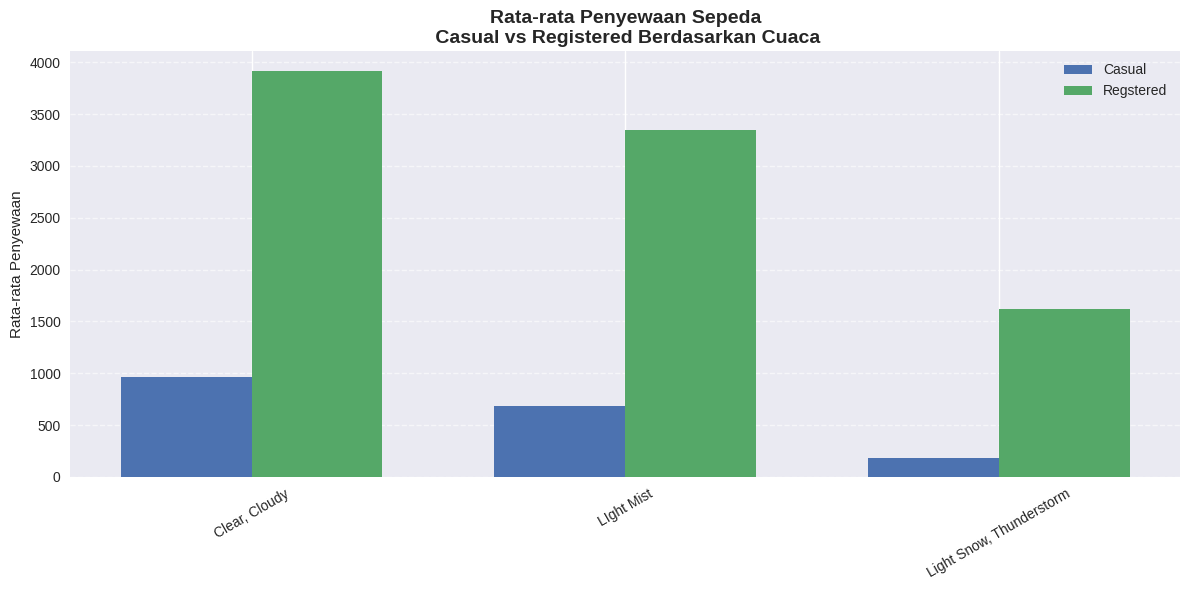

In [ ]:
x = np.arange(len(cuaca.index))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, cuaca['casual']['mean'], width, label='Casual')
plt.bar(x + width/2, cuaca['registered']['mean'], width, label='Regstered')

plt.xticks(x, cuaca.index, rotation=30)
plt.title('Rata-rata Penyewaan Sepeda\n Casual vs Registered Berdasarkan Cuaca', fontsize=14, fontweight='bold')
plt.ylabel('Rata-rata Penyewaan')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

5. Apakah kecepatan angin memiliki hubungan terhadap jumlah penyewaan sepeda, dan apakah pengaruhnya signifikan?

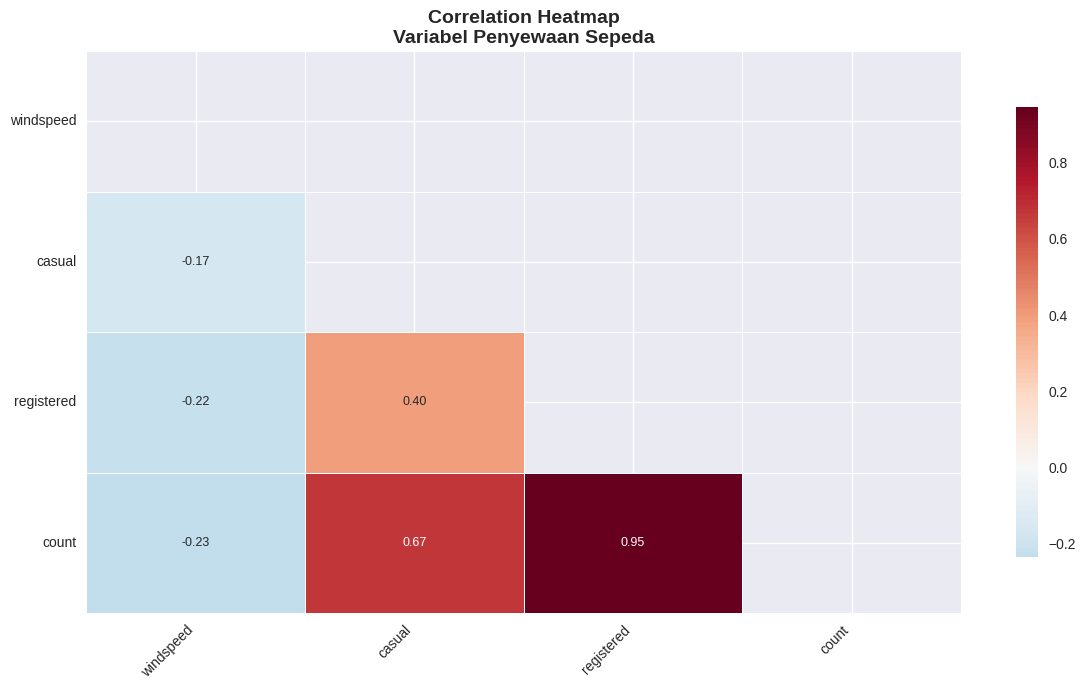

In [ ]:
fig, ax = plt.subplots(figsize=(12,7))

correlation_matrix = hari_df.corr(numeric_only=True)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    annot=True,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9}
)

plt.title("Correlation Heatmap\nVariabel Penyewaan Sepeda", fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


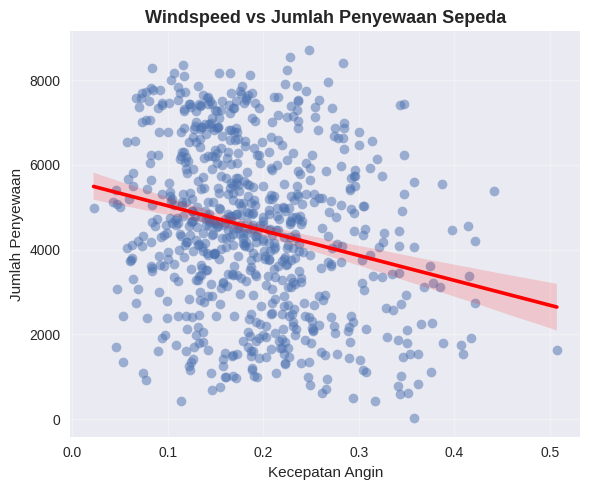

Korelasi: -0.235
p-value: 1.3599586778864978e-10


In [ ]:
plt.figure(figsize=(6,5))

sns.regplot(
    x='windspeed',
    y='count',
    data=hari_df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title('Windspeed vs Jumlah Penyewaan Sepeda',
          fontsize=13, fontweight='bold')
plt.xlabel('Kecepatan Angin')
plt.ylabel('Jumlah Penyewaan')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr, p_value = stats.pearsonr(hari_df['windspeed'], hari_df['count'])

print("Korelasi:", round(corr, 3))
print("p-value:", p_value)

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

1. **Conclusion pertanyaan 1:** Berdasarkan hasil
agregasi jumlah penyewaan sepeda menurut hari dalam seminggu, diperoleh sebagai berikut:
   *   Nilai rata-rata menunjukkan bahwa aktivitas penyewaan relatif stabil sepanjang minggu, namun tatp ada kecenderungan tertentu.
   *   Secara spesifik, hari Jumat memiliki tingkat penyewaan tertinggi, dengan rata-rata penyewaan sekitar 4.690 sepeda per hari. Dan hari Minggu menunjukkan rata-rata penyewaan terendah sekitar 4.229 sepeda per hari.

2.  **Conclusion pertanyaan 2:** Berdasarkan hasil agregasi jumlah pengguna casual dan regstered pada tiap musim, diperoleh sebagai berikut:
    *   Untuk pengguna casul, terlihat variasi yang cukup besar antar musim. Rata-rata penggunaan ertinggi terjadi pada Fall sekitar 1.203 sepeda dan Summer sekitar 1.106 sepeda, sementara pada Spring sekitar 335 sepeda terjadi penurunan yang sangat signifikan, dan Winter sekitar 729 sepeda. Ini menunjukkan bahwa pengguna Casual sangat dipengaruhi oleh kondisi musim.
    *   Untuk pengguna Regstered menunjukkan pola yang lebi stabil. Meskipun terdapat peningkatan pada Fall sekitar 4.442 sepeda dan relatif tinggi pada Winter sekitar 3.999 sepeda serta Summer sekitar 3.886 sepeda, penurunan pada Spring sekitar 2.269 tidak sedrastis yang terjadi pada pengguna Casual. Hal ini menunjukkan bahwa pengguna Regustered cenderung tetap menggunakan sepeda secara konsisten.

3. **Conclusion pertanyaan 3:** Berdasarkan hasil perhitungan, diperoleh penyewaan sepeda paling tinggi terjadi pada pukul 17.00 atau jam 5 sore, dan secara keseluruhan distribusi penggunaan mengikuti pola aktivitas sehari-hari, dengan dua puncak utama pada pagi dan sore hari. Hal ini menunjukkan bahwa penyewaan sepeda banyak digunakan sebagai sarana transportasi rutin bukan hanya untuk rekreasi.

4. **Conclusion pertanyaan 4:** Berdasarkan hasil agregasi dapat disusun kesimpulan mengenai kondisi cuaca terhadap pola penyewaan sepeda sebagai berikut.
Secara umum, terdapat perbedaan yang jelas antara pengguna Casual dan Registered pada setiap kondisi cuaca. Pada semua kategori cuaca, jumlah rata-rata pengguna registered selalu lebih tinggi dibandingkan Casual, yang menunjukkan bahwa pengguna Regsiteres merupakan kontributor utama dalam total penyewaan sepeda. Ini menunjukkan bahwa cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Meskipun pengguna Registered tetap mendominasi dalam semua kondisi, pengguna Casual menunjukkan sensitivitas yang lebih tinggi terhadap perubahan cuaca. Selain itu, cuaca cerah menjadi kondisi dengan tingkat penyewaan sepeda tertinggi.

5. **Conclusion pertanyaan 5:** Berdasarkan hasil korelasi anatara kecepatan angin dan jumlah penyewaan sepeda diperoleh,
Secara umum, kecepatan angin memiliki hubungan dengan jumlah penyewaan sepeda, namun hubungan tersebut bersifat lemah dan cenderung negatif. Artinya, ketika kecepatan angin meningkat, jumlah penyewaan sepeda cenderung sedikit menurun, tetapi penurunannya tidak signifikan secara besar. Dengan demikian, faktor ini bukan penentu utama dalam variasi jumlah penyewaan sepeda dibandingkan variabel lain seperti suhu dan kondisi cuaca.



